/tmp/ipykernel_86/2425509256.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


    timestamp  packet_count                status
0  2026-01-01          1200                Normal
1  2026-02-01          1300                Normal
2  2026-03-01          1250                Normal
3  2026-04-01          1400                Normal
4  2026-05-01          1500                Normal
5  2026-06-01          1700                Normal
6  2026-07-01          1800                Normal
7  2026-08-01          1300                Normal
8  2026-09-01          1350                Normal
9  2026-10-01          1280                Normal
10 2026-11-01          1450                Normal
11 2026-12-01          1550                Normal
12 2026-01-13          1750                Normal
13 2026-01-14          1850                Normal
14 2026-01-15          1400                Normal
15 2026-01-16          1450                Normal
16 2026-01-17          1380                Normal
17 2026-01-18          1500                Normal
18 2026-01-19          1600                Normal


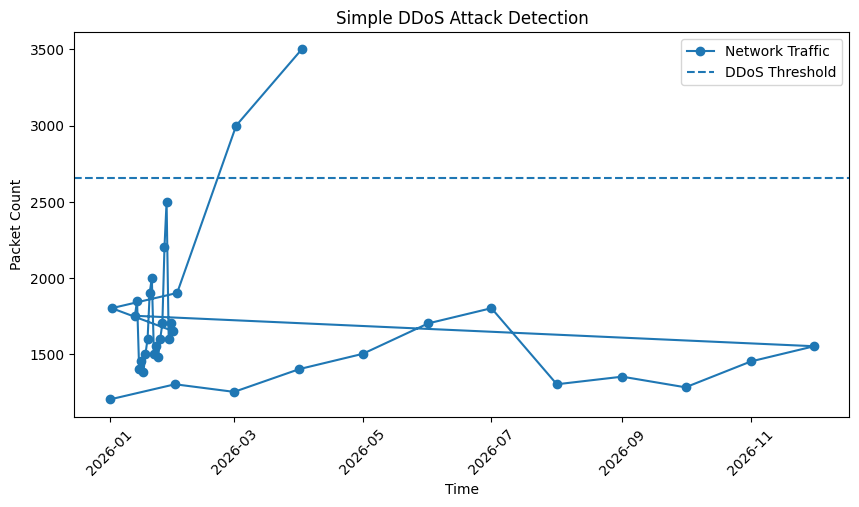

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("./dataset/network_traffic.csv")

# Convert timestamp column
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Calculate threshold
threshold = df["packet_count"].mean() + 2 * df["packet_count"].std()

# Detect possible DDoS attack
df["status"] = df["packet_count"].apply(
    lambda x: "Possible DDoS Attack" if x > threshold else "Normal"
)

print(df)
print("DDoS Threshold:", threshold)

# Plot graph
plt.figure(figsize=(10,5))
plt.plot(df["timestamp"], df["packet_count"], marker="o", label="Network Traffic")
plt.axhline(y=threshold, linestyle="--", label="DDoS Threshold")
plt.xlabel("Time")
plt.ylabel("Packet Count")
plt.title("Simple DDoS Attack Detection")
plt.legend()
plt.xticks(rotation=45)
plt.show()